# Data Preprocessing

This notebook prepares the selected modelling dataset for machine learning. The dataset was generated in `02_Data_Audit_and_Feature_Selection.ipynb` and contains the retained trace element predictor suite.

In [1]:
# =============================================================================
# Environment setup
# =============================================================================

import os
os.environ["OMP_NUM_THREADS"] = "1"

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

from sklearn.preprocessing import StandardScaler, RobustScaler

ROOT_DIR = Path.cwd().parent

DATA_DIR = ROOT_DIR / "model_data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"

DATA_FILE = RAW_DIR / "Data_Input.csv"

EXPORT_DIR = ROOT_DIR / "model_output/exports"
FIGURE_DIR = ROOT_DIR / "model_output/figures"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
EXPORT_DIR.mkdir(exist_ok=True)
FIGURE_DIR.mkdir(exist_ok=True)

print("Environment initialised.")
print(f"Root directory   : {ROOT_DIR}")
print(f"Raw data         : {DATA_FILE}")
print(f"Processed data   : {PROCESSED_DIR}")
print(f"Export directory : {EXPORT_DIR}")
print(f"Figure directory : {FIGURE_DIR}")

Environment initialised.
Root directory   : C:\Users\d67199rs\Documents\GitHub\RahulS_LaTeCT
Raw data         : C:\Users\d67199rs\Documents\GitHub\RahulS_LaTeCT\model_data\raw\Data_Input.csv
Processed data   : C:\Users\d67199rs\Documents\GitHub\RahulS_LaTeCT\model_data\processed
Export directory : C:\Users\d67199rs\Documents\GitHub\RahulS_LaTeCT\model_output\exports
Figure directory : C:\Users\d67199rs\Documents\GitHub\RahulS_LaTeCT\model_output\figures


## 1. Load Modelling Dataset

Load the fixed modelling dataset created after trace element retention assessment.

In [2]:
# =============================================================================
# Load modelling dataset
# =============================================================================

DATA_FILE = PROCESSED_DIR / "Modelling_Dataset.csv"

df = pd.read_csv(DATA_FILE, encoding="utf-8")

META = ["Series", "Location", "Rock Type"]
ELEMENTS = [col for col in df.columns if col not in META]

print("Modelling dataset loaded.\n")

print(f"Analyses   : {len(df)}")
print(f"Elements   : {len(ELEMENTS)}")
print(f"Orogenic   : {(df['Series'] == 'Orogenic').sum()}")
print(f"Anorogenic : {(df['Series'] == 'Anorogenic').sum()}")
print(f"Locations  : {df['Location'].nunique()}")

series_summary = (
    df.groupby("Series")
    .agg(
        Analyses=("Series", "size"),
        Locations=("Location", "nunique")
    )
)

print("\nSeries summary")
display(series_summary)

Modelling dataset loaded.

Analyses   : 445
Elements   : 12
Orogenic   : 289
Anorogenic : 156
Locations  : 22

Series summary


,Analyses,Locations
Series,,
Anorogenic,156,7
Orogenic,289,15


## 2. Distribution Assessment

Assess the distribution of the retained trace element concentrations to determine whether a logarithmic transformation is appropriate prior to multivariate analysis and machine learning.

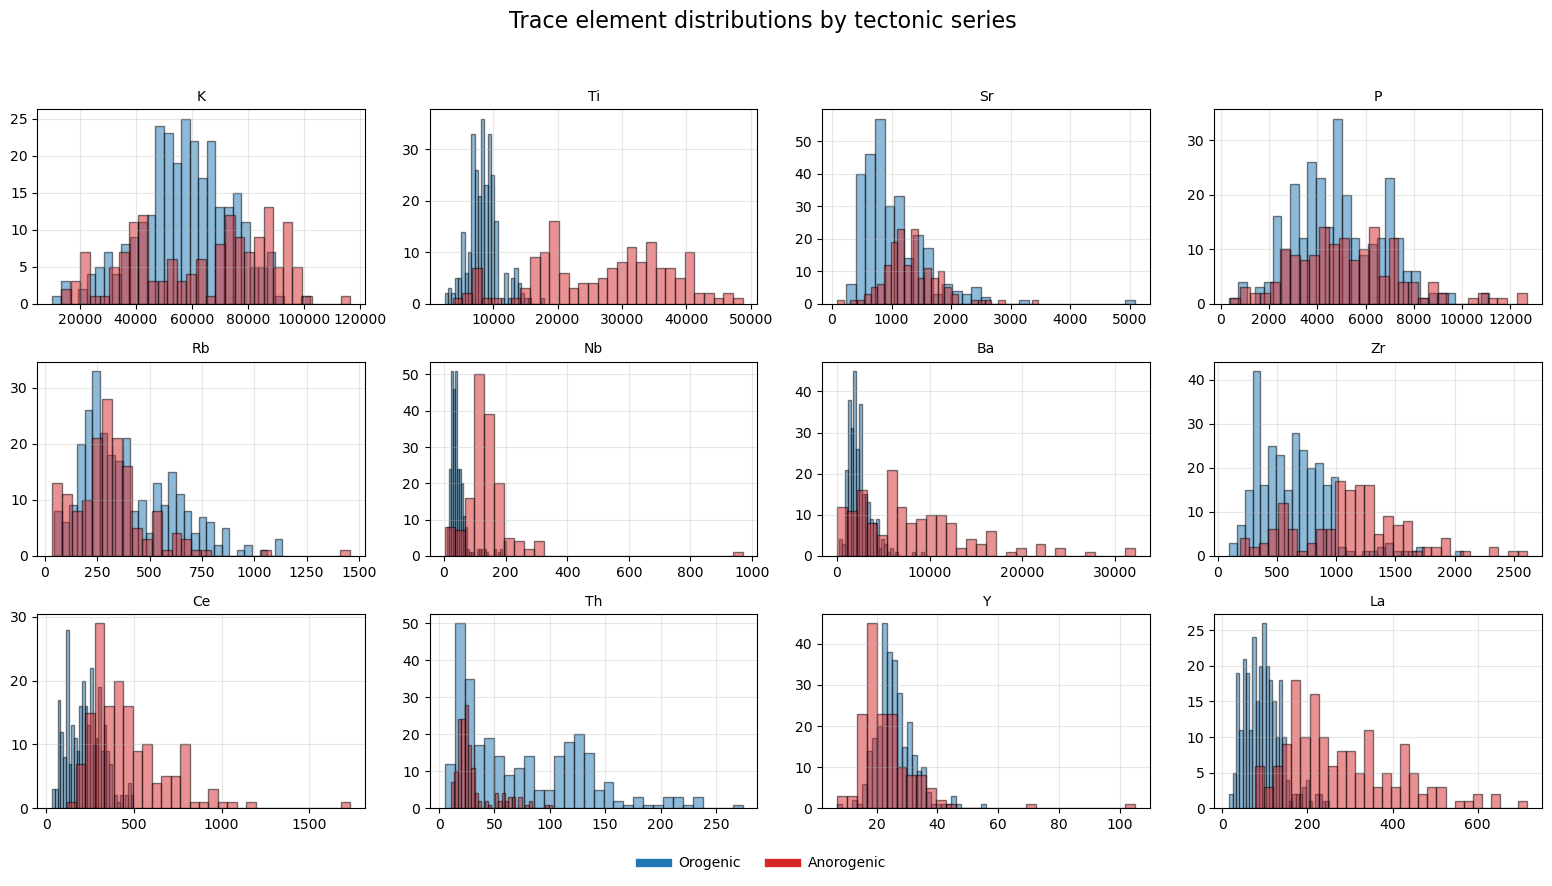

Saved: C:\Users\d67199rs\Documents\GitHub\RahulS_LaTeCT\model_output\figures\05_feature_distributions_raw.png


In [3]:
# =============================================================================
# Feature distributions by tectonic series
# =============================================================================

ELEMENTS = [
    col for col in df.columns
    if col not in ["Series", "Location", "Rock Type"]
]

ncols = 4
nrows = int(np.ceil(len(ELEMENTS) / ncols))

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(4 * ncols, 3 * nrows)
)

axes = np.array(axes).flatten()

series_colours = {
    "Orogenic": "tab:blue",
    "Anorogenic": "tab:red"
}

for ax, element in zip(axes, ELEMENTS):

    ax.hist(
        df.loc[df["Series"] == "Orogenic", element],
        bins=30,
        color=series_colours["Orogenic"],
        alpha=0.5,
        edgecolor="black"
    )

    ax.hist(
        df.loc[df["Series"] == "Anorogenic", element],
        bins=30,
        color=series_colours["Anorogenic"],
        alpha=0.5,
        edgecolor="black"
    )

    ax.set_title(element, fontsize=10)
    ax.grid(alpha=0.3)

for ax in axes[len(ELEMENTS):]:
    ax.remove()

legend_handles = [
    Line2D([0], [0], color="tab:blue", lw=6, label="Orogenic"),
    Line2D([0], [0], color="tab:red", lw=6, label="Anorogenic")
]

fig.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=2,
    frameon=False,
    bbox_to_anchor=(0.5, 0.01)
)

fig.suptitle("Trace element distributions by tectonic series", fontsize=16)

plt.tight_layout(rect=[0.02, 0.05, 1, 0.95])

outpath = FIGURE_DIR / "05_feature_distributions_raw.png"
plt.savefig(outpath, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved: {outpath}")

## 3. Log Transformation

Trace element concentrations are transformed using log10 to reduce right skewness and make element distributions more suitable for multivariate analysis.

In [4]:
# =============================================================================
# Log10 transformation
# =============================================================================

X_raw = df[ELEMENTS].copy()

if (X_raw <= 0).any().any():
    raise ValueError("Log10 transformation cannot be applied because non-positive values are present.")

X_log = np.log10(X_raw)

df_log = df[["Series", "Location", "Rock Type"]].copy()
df_log[ELEMENTS] = X_log

print("Log10 transformation applied.")

Log10 transformation applied.


## 4. Z Score Standardisation

The log transformed trace element concentrations are standardised to zero mean and unit variance for analyses that are sensitive to variable scale, including principal component analysis and support vector machines.

In [5]:
# =============================================================================
# Z score standardisation
# =============================================================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = pd.DataFrame(
    scaler.fit_transform(df_log[ELEMENTS]),
    columns=ELEMENTS,
    index=df_log.index
)

df_scaled = df_log[["Series", "Location", "Rock Type"]].copy()
df_scaled[ELEMENTS] = X_scaled

## 5. Feature Correlation Assessment

Assess pairwise Pearson correlations between the standardised trace element predictors to identify groups of strongly correlated variables and evaluate the overall covariance structure of the modelling dataset.

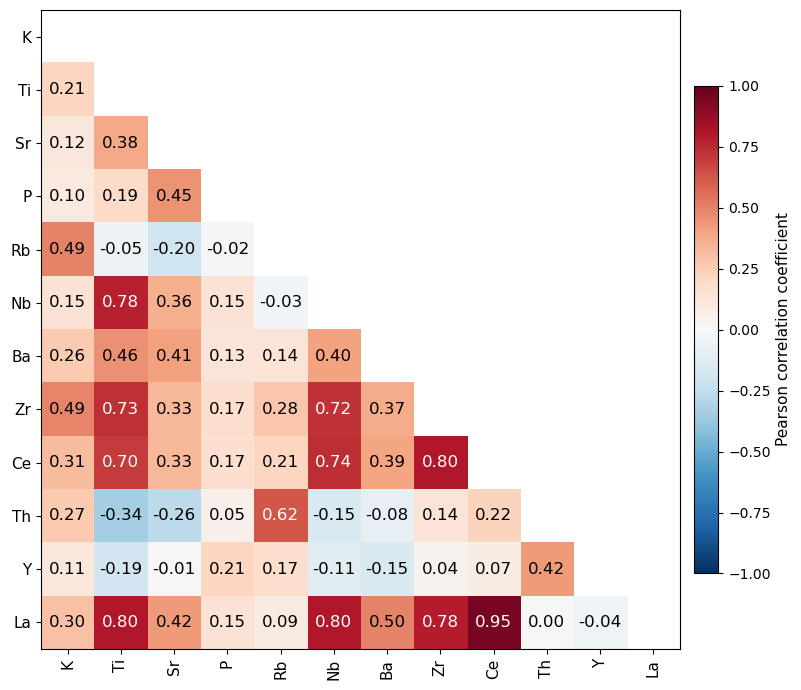

Saved: C:\Users\d67199rs\Documents\GitHub\RahulS_LaTeCT\model_output\figures\06_feature_correlation_matrix.png


In [6]:
# =============================================================================
# Feature correlation matrix
# =============================================================================

corr = df_scaled[ELEMENTS].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
corr_plot = corr.mask(mask)

fig, ax = plt.subplots(figsize=(8, 7))

im = ax.imshow(corr_plot, cmap="RdBu_r", vmin=-1, vmax=1)

ax.set_xticks(range(len(ELEMENTS)))
ax.set_xticklabels(ELEMENTS, rotation=90, fontsize=11)
ax.set_yticks(range(len(ELEMENTS)))
ax.set_yticklabels(ELEMENTS, fontsize=11)

for i in range(len(ELEMENTS)):
    for j in range(i):
        value = corr.iloc[i, j]
        colour = "white" if abs(value) >= 0.6 else "black"
        ax.text(j, i, f"{value:.2f}", ha="center", va="center", fontsize=12, color=colour)

cbar = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.02)
cbar.set_label("Pearson correlation coefficient", fontsize=11)
cbar.ax.tick_params(labelsize=10)

plt.tight_layout()

outpath = FIGURE_DIR / "06_feature_correlation_matrix.png"
plt.savefig(outpath, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved: {outpath}")

In [7]:
# =============================================================================
# Strong feature correlations
# =============================================================================

corr_pairs = (
    corr.where(np.tril(np.ones(corr.shape), k=-1).astype(bool))
        .stack()
        .rename("r")
        .reset_index()
)

corr_pairs.columns = ["Element 1", "Element 2", "Correlation"]

corr_pairs["Correlation"] = corr_pairs["Correlation"].round(2)

corr_pairs = (
    corr_pairs.loc[corr_pairs["Correlation"].abs() >= 0.80]
              .sort_values("Correlation", key=np.abs, ascending=False)
              .reset_index(drop=True)
)

display(corr_pairs)

,Element 1,Element 2,Correlation
0,La,Ce,0.95
1,Ce,Zr,0.80
2,La,Ti,0.80
3,La,Nb,0.80


## 6. Export Processed Datasets

Export the log transformed and log transformed plus Z score standardised datasets for use in subsequent unsupervised and supervised machine learning analyses.

In [8]:
# =============================================================================
# Export processed datasets
# =============================================================================

outpath = PROCESSED_DIR / "Modelling_Dataset_Log.csv"
df_log.to_csv(outpath, index=False)
print(f"Saved: {outpath}")

outpath = PROCESSED_DIR / "Modelling_Dataset_Log_ZScaled.csv"
df_scaled.to_csv(outpath, index=False)
print(f"Saved: {outpath}")

Saved: C:\Users\d67199rs\Documents\GitHub\RahulS_LaTeCT\model_data\processed\Modelling_Dataset_Log.csv
Saved: C:\Users\d67199rs\Documents\GitHub\RahulS_LaTeCT\model_data\processed\Modelling_Dataset_Log_ZScaled.csv
